## The ResNet-34 Encoder Class

In [19]:
import torch
import torch.nn as nn
from torchvision.models import resnet34, ResNet34_Weights

class ResNet34Encoder(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        
        # Load the base pre-trained ResNet-34 model
        weights = ResNet34_Weights.DEFAULT if pretrained else None
        base_resnet = resnet34(weights=weights)
        
        # Initial stem layer (converts 3 channels to 64 channels)
        self.init_conv = nn.Sequential(
            base_resnet.conv1,
            base_resnet.bn1,
            base_resnet.relu
        )
        self.maxpool = base_resnet.maxpool
        
        # the 4 ResNet stages
        self.layer1 = base_resnet.layer1  # Stage 1: channels = 64
        self.layer2 = base_resnet.layer2  # Stage 2: channels = 128
        self.layer3 = base_resnet.layer3  # Stage 3: channels = 256
        self.layer4 = base_resnet.layer4  # Stage 4: channels = 512 (Bottleneck)
        
    def forward(self, x):
        # Let's assume input x shape is [Batch, 3, 256, 256]
        
        x1 = self.init_conv(x)          # Shape: [B, 64, 128, 128]  (Skip connection 1)
        
        x_pool = self.maxpool(x1)       # Shape: [B, 64, 64, 64]
        x2 = self.layer1(x_pool)        # Shape: [B, 64, 64, 64]   (Skip connection 2)
        
        x3 = self.layer2(x2)            # Shape: [B, 128, 32, 32]  (Skip connection 3)
        x4 = self.layer3(x3)            # Shape: [B, 256, 16, 16]  (Skip connection 4)
        x5 = self.layer4(x4)            # Shape: [B, 512, 8, 8]    (Bottleneck layer)
        
        # Return the bottleneck and all skip connections
        return x5, [x4, x3, x2, x1]


In [20]:
class AttentionGate(nn.Module):
    """
        F_g: Channels in the gating signal (Decoder feature map)
        F_l: Channels in the skip connection (Encoder feature map)
        F_int: Intermediate channels for the 1x1 convolutions
    """
    def __init__(self, F_g , F_l , F_int):
        super().__init__()
        self.W_g = nn.Conv2d(F_g , F_int , 1) #W_g block
        self.W_x = nn.Conv2d(F_l , F_int , 1) #W_l block
        self.psi = nn.Conv2d(F_int , 1,1) #psi block
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, g , x):
        g1 = self.W_g(g) # F_int × H_g × W_g
        x1 = self.W_x(x) # F_int × H_g × W_g
        psi = self.relu(g1 + x1) # @ then relu
        psi = self.sigmoid(self.psi(psi)) # psi then sigmoid → 1 × H × W
        return x*psi

## The ResNet-34 Decoder Class

In [21]:
class DecoderBlock(nn.Module):
    """
    Padded double convolution block for the decoder path to maintain spatial resolution.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)


class ResNet34Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 1. Upsampling blocks (ConvTranspose2d)
        self.upconv1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.upconv3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.upconv4 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.upconv5 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        
        # 2. Attention Gates (gating = decoder feature map, skip = encoder feature map)
        self.attn1 = AttentionGate(F_g=256, F_l=256, F_int=128)
        self.attn2 = AttentionGate(F_g=128, F_l=128, F_int=64)
        self.attn3 = AttentionGate(F_g=64,  F_l=64,  F_int=32)
        self.attn4 = AttentionGate(F_g=64,  F_l=64,  F_int=32)
        
        # 3. Double convolution blocks (takes concatenated channels)
        self.dec_block1 = DecoderBlock(512, 256)  # 256 (upconv) + 256 (attn skip)
        self.dec_block2 = DecoderBlock(256, 128)  # 128 (upconv) + 128 (attn skip)
        self.dec_block3 = DecoderBlock(128, 64)   # 64 (upconv) + 64 (attn skip)
        self.dec_block4 = DecoderBlock(128, 64)   # 64 (upconv) + 64 (attn skip)
        self.dec_block5 = DecoderBlock(32, 32)    # 32 (final upsampled)
        
    def crop(self, enc_features, x):
        """
        Helper function to center crop encoder skip connections to match 
        the decoder's upsampled feature dimensions.
        """
        _, _, H, W = x.shape
        if enc_features.shape[-2:] != (H, W):
            diffY = enc_features.size()[2] - H
            diffX = enc_features.size()[3] - W
            return enc_features[:, :, diffY // 2 : diffY // 2 + H, diffX // 2 : diffX // 2 + W]
        return enc_features

    def forward(self, x, skip_connections):
        # x is the bottleneck (x5) from the encoder: [B, 512, 8, 8]
        # skip_connections is a list: [x4 (256 ch), x3 (128 ch), x2 (64 ch), x1 (64 ch)]
        x4, x3, x2, x1 = skip_connections
        
        # Step 1: Bottleneck to Stage 3 (x4)
        g1 = self.upconv1(x)                             # Shape: [B, 256, 16, 16]
        x4_cropped = self.crop(x4, g1)
        a1 = self.attn1(g=g1, x=x4_cropped)               # Apply Attention Gate
        x = self.dec_block1(torch.cat((a1, g1), dim=1))  # Cat to 512 ch -> Output 256 ch
        
        # Step 2: Stage 3 to Stage 2 (x3)
        g2 = self.upconv2(x)                             # Shape: [B, 128, 32, 32]
        x3_cropped = self.crop(x3, g2)
        a2 = self.attn2(g=g2, x=x3_cropped)
        x = self.dec_block2(torch.cat((a2, g2), dim=1))  # Cat to 256 ch -> Output 128 ch
        
        # Step 3: Stage 2 to Stage 1 (x2)
        g3 = self.upconv3(x)                             # Shape: [B, 64, 64, 64]
        x2_cropped = self.crop(x2, g3)
        a3 = self.attn3(g=g3, x=x2_cropped)
        x = self.dec_block3(torch.cat((a3, g3), dim=1))  # Cat to 128 ch -> Output 64 ch
        
        # Step 4: Stage 1 to Stem layer (x1)
        g4 = self.upconv4(x)                             # Shape: [B, 64, 128, 128]
        x1_cropped = self.crop(x1, g4)
        a4 = self.attn4(g=g4, x=x1_cropped)
        x = self.dec_block4(torch.cat((a4, g4), dim=1))  # Cat to 128 ch -> Output 64 ch
        
        # Step 5: Final upsample to original resolution (e.g. 256x256)
        g5 = self.upconv5(x)                             # Shape: [B, 32, 256, 256]
        x = self.dec_block5(g5)                          # Output 32 ch
        
        return x


## Combined Model Class 

In [22]:
class ResNet34AttentionUNet(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()
        
        # Instantiate your modular encoder and decoder
        self.encoder = ResNet34Encoder(pretrained=pretrained)
        self.decoder = ResNet34Decoder()
        
        # Final projection layer (reduces 32 channels to your output class count, e.g. 1)
        self.final_conv = nn.Conv2d(32, num_classes, kernel_size=1)
        
    def forward(self, x):
        # 1. Pass input through encoder
        # Returns bottleneck feature map (x5) and the list of skip connections [x4, x3, x2, x1]
        bottleneck, skip_connections = self.encoder(x)
        
        # 2. Pass bottleneck and skip connections through decoder
        dec_output = self.decoder(bottleneck, skip_connections)
        
        # 3. Align shape if final decoder output differs slightly from input image shape
        if dec_output.shape[-2:] != x.shape[-2:]:
            dec_output = F.interpolate(dec_output, size=x.shape[-2:], mode='bilinear', align_corners=True)
            
        # 4. Final 1x1 convolution
        out = self.final_conv(dec_output)
        return out


## training starts :

#### Imports

In [23]:
import os
import xml.etree.ElementTree as ET
import numpy as np
import cv2
from PIL import Image
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
import random
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.nn.functional as F



#### seeding

In [24]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(seed=42)
print("Random seed initialized to 42.")


Random seed initialized to 42.


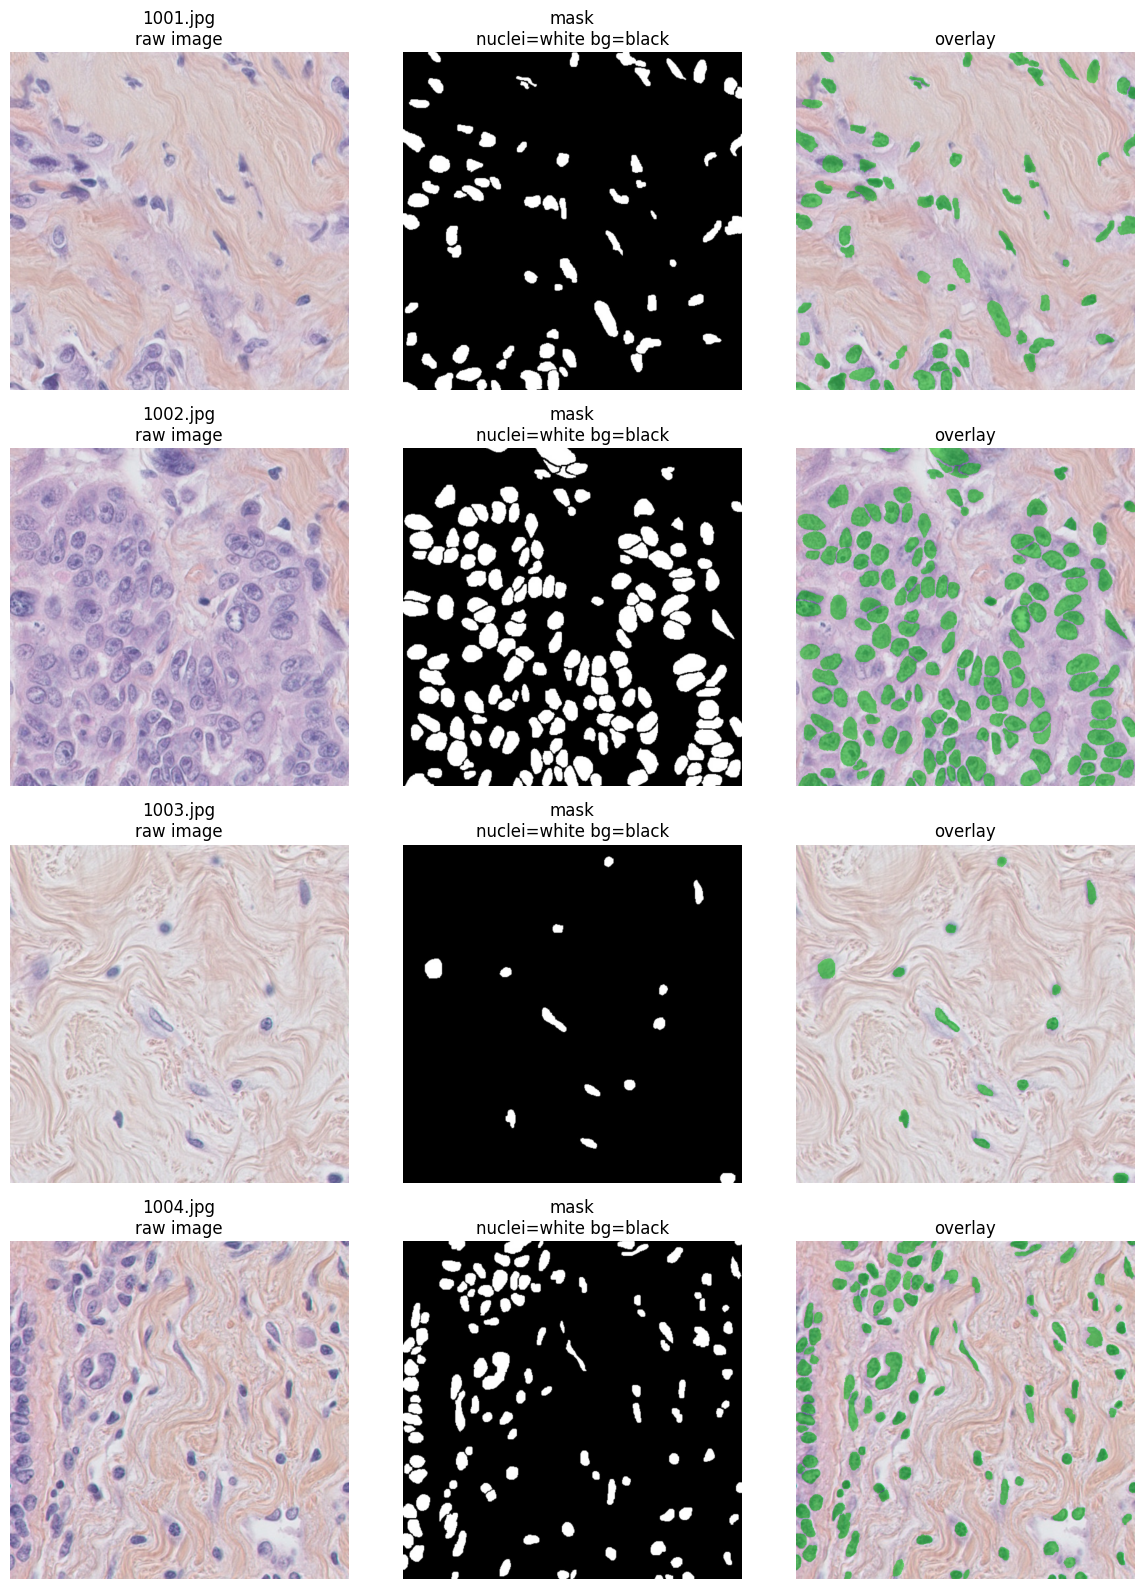

saved to visualise_train.png


In [25]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def visualise_samples(split="train", n=4):
    # Dynamic paths based on train/val split
    img_dir  = f"/kaggle/input/datasets/momoketchum/monuseg-2018-splitted/dataset/{split}/images"
    mask_dir = f"/kaggle/input/datasets/momoketchum/monuseg-2018-splitted/dataset/{split}/masks"
    files    = sorted(os.listdir(img_dir))[:n]

    fig, axes = plt.subplots(n, 3, figsize=(12, n*4))

    for i, fname in enumerate(files):
        # FIX: Explicitly convert image to RGB to handle grayscale files
        img  = np.array(Image.open(os.path.join(img_dir,  fname)).convert("RGB"))
        mask = np.array(Image.open(os.path.join(mask_dir, fname)).convert("L"))

        # overlay: green tint on nuclei
        overlay = img.copy()
        overlay[mask > 127] = (overlay[mask > 127] * 0.5 + np.array([0, 200, 0]) * 0.5).astype(np.uint8)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"{fname[:20]}\nraw image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title("mask\nnuclei=white bg=black")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("overlay")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.savefig(f"./visualise_{split}.png", dpi=100)
    plt.show()
    print(f"saved to visualise_{split}.png")

visualise_samples("train", n=4)


── train split ──
total images   : 880
image sizes    : {(640, 640)}
fg ratio       : min=0.002  max=0.325  mean=0.111
nuclei per img : min=2  max=297  mean=75.8


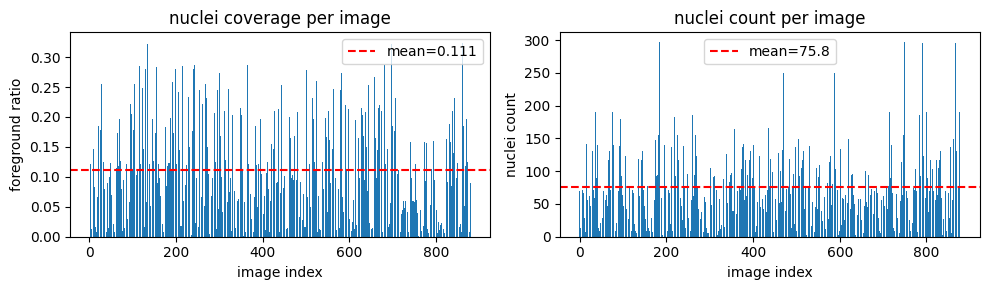

── val split ──
total images   : 165
image sizes    : {(640, 640)}
fg ratio       : min=0.002  max=0.323  mean=0.117
nuclei per img : min=2  max=297  mean=79.0


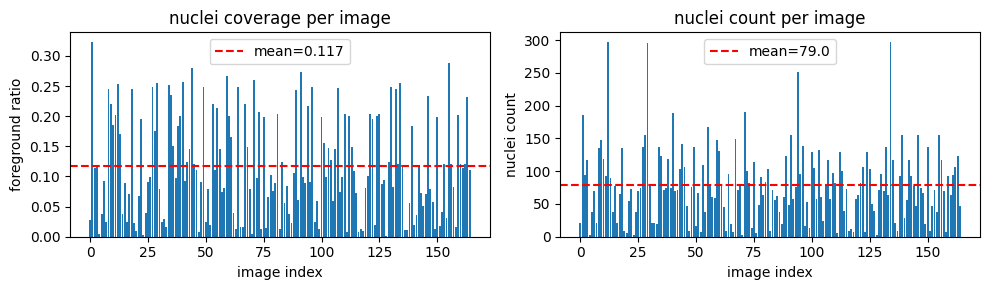

In [26]:
def dataset_stats(split="train"):
    # Dynamic paths based on train/val split
    img_dir  = f"/kaggle/input/datasets/momoketchum/monuseg-2018-splitted/dataset/{split}/images"
    mask_dir = f"/kaggle/input/datasets/momoketchum/monuseg-2018-splitted/dataset/{split}/masks"
    files    = sorted(os.listdir(img_dir))

    sizes, nuclei_counts, fg_ratios = [], [], []

    for fname in files:
        # FIX: Ensure both image (RGB) and mask (Grayscale) are converted to the correct formats
        img  = np.array(Image.open(os.path.join(img_dir,  fname)).convert("RGB"))
        mask = np.array(Image.open(os.path.join(mask_dir, fname)).convert("L"))

        sizes.append(img.shape[:2])

        # foreground ratio (how much of image is nuclei)
        fg = (mask > 127).sum() / mask.size
        fg_ratios.append(fg)

        # rough nucleus count via connected components
        binary = (mask > 127).astype(np.uint8)
        num_labels, _ = cv2.connectedComponents(binary)
        nuclei_counts.append(num_labels - 1)  # subtract background label

    print(f"── {split} split ──")
    print(f"total images   : {len(files)}")
    print(f"image sizes    : {set(map(tuple, sizes))}")
    print(f"fg ratio       : min={min(fg_ratios):.3f}  max={max(fg_ratios):.3f}  mean={np.mean(fg_ratios):.3f}")
    print(f"nuclei per img : min={min(nuclei_counts)}  max={max(nuclei_counts)}  mean={np.mean(nuclei_counts):.1f}")

    # plot fg ratio distribution
    plt.figure(figsize=(10, 3))
    plt.subplot(1, 2, 1)
    plt.bar(range(len(fg_ratios)), fg_ratios)
    plt.axhline(np.mean(fg_ratios), color='red', linestyle='--', label=f"mean={np.mean(fg_ratios):.3f}")
    plt.xlabel("image index")
    plt.ylabel("foreground ratio")
    plt.title("nuclei coverage per image")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.bar(range(len(nuclei_counts)), nuclei_counts)
    plt.axhline(np.mean(nuclei_counts), color='red', linestyle='--', label=f"mean={np.mean(nuclei_counts):.1f}")
    plt.xlabel("image index")
    plt.ylabel("nuclei count")
    plt.title("nuclei count per image")
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"./stats_{split}.png", dpi=100)
    plt.show()

dataset_stats("train")
dataset_stats("val")


## Dataset management :)

In [27]:
import torch
from torch.utils.data import Dataset

class MoNuSegDataset(torch.utils.data.Dataset):
    def __init__(self, image_dir, mask_dir, is_train=True, crop_size=572):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.filenames = sorted([f for f in os.listdir(image_dir) if not f.startswith('.')])

        if is_train:
            self.transform = A.Compose([
                A.RandomCrop(crop_size, crop_size),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                ToTensorV2()
            ])
        else:
            self.transform = A.Compose([
                A.CenterCrop(crop_size, crop_size),
                ToTensorV2()
            ])

    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, idx):
        fname = self.filenames[idx]

        image_path = os.path.join(self.image_dir, fname)
        mask_path = os.path.join(self.mask_dir, fname)

        image = np.array(Image.open(image_path).convert("RGB"))       # (H,W,3) uint8
        mask  = np.array(Image.open(mask_path).convert("L"))          # (H,W) uint8

        augmented = self.transform(image=image, mask=mask)
        image_tensor = augmented["image"].float() / 255.0   # (3,572,572) float 0-1
        mask_tensor  = augmented["mask"].float()  / 255.0   # (572,572) float 0-1
        mask_tensor  = (mask_tensor > 0.5).float().unsqueeze(0) # (1,572,572) binary float tensor

        return image_tensor, mask_tensor


In [28]:
# Kaggle Input dataset directories
DATASET_BASE = "/kaggle/input/datasets/momoketchum/monuseg-2018-splitted/dataset"

TRAIN_IMG_DIR  = f"{DATASET_BASE}/train/images"
TRAIN_MASK_DIR = f"{DATASET_BASE}/train/masks"

VAL_IMG_DIR    = f"{DATASET_BASE}/val/images"
VAL_MASK_DIR   = f"{DATASET_BASE}/val/masks"

TEST_IMG_DIR   = f"{DATASET_BASE}/test/images"
TEST_MASK_DIR  = f"{DATASET_BASE}/test/masks"

# Initialize Datasets
train_ds = MoNuSegDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, is_train=True, crop_size=572)
val_ds   = MoNuSegDataset(VAL_IMG_DIR,   VAL_MASK_DIR,   is_train=False, crop_size=572)
test_ds  = MoNuSegDataset(TEST_IMG_DIR,  TEST_MASK_DIR,  is_train=False, crop_size=572)

# Initialize Loaders (num_workers=2 is stable and faster on Kaggle Linux VMs)
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

print(f"train samples: {len(train_ds)} | val samples: {len(val_ds)} | test samples: {len(test_ds)}")

# Quick shape check
imgs, masks = next(iter(train_loader))
print(f"image batch shape: {imgs.shape}")  # Expected: (2, 3, 572, 572)
print(f"mask batch shape:  {masks.shape}") # Expected: (2, 1, 572, 572)


train samples: 880 | val samples: 165 | test samples: 55
image batch shape: torch.Size([2, 3, 572, 572])
mask batch shape:  torch.Size([2, 1, 572, 572])


In [29]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        bce  = self.bce(pred, target)
        pred = torch.sigmoid(pred)
        smooth = 1e-6
        intersection = (pred * target).sum(dim=(2, 3))
        dice = 1 - (2 * intersection + smooth) / \
               (pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) + smooth)
        return self.bce_weight * bce + (1 - self.bce_weight) * dice.mean()

def dice_score(pred, target):
    pred   = (torch.sigmoid(pred) > 0.5).float()
    smooth = 1e-6
    intersection = (pred * target).sum(dim=(2, 3))
    return ((2 * intersection + smooth) /
            (pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) + smooth)).mean().item()

In [30]:
from tqdm import tqdm

# ── config ─────────────────────────────────────
EPOCHS    = 10
LR        = 1e-4
BATCH     = 2
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using: {DEVICE}")

# ── model, optimizer, loss ──────────────────────
model = ResNet34AttentionUNet(num_classes=1, pretrained=True).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
criterion = BCEDiceLoss()

# ── metric trackers ─────────────────────────────
history = {"train_loss": [], "val_loss": [], "val_dice": []}
best_dice = 0.0

# ── training loop ───────────────────────────────
for epoch in range(1, EPOCHS + 1):

    # train
    model.train()
    train_loss = 0.0

    with tqdm(train_loader, desc=f"epoch {epoch:02d}/{EPOCHS} [train]", leave=False) as pbar:
        for imgs, masks in pbar:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            preds = model(imgs)
            masks = TF.center_crop(masks, preds.shape[-2:])  # 572→388

            loss  = criterion(preds, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
            optimizer.step()

            train_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    # val
    model.eval()
    val_loss = 0.0
    val_dice = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds       = model(imgs)
            masks       = TF.center_crop(masks, preds.shape[-2:])
            val_loss   += criterion(preds, masks).item()
            val_dice   += dice_score(preds, masks)

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)
    val_dice   /= len(val_loader)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)

    print(f"epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss: {train_loss:.4f} | "
          f"val_loss: {val_loss:.4f} | "
          f"val_dice: {val_dice:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "best_attention_unet.pth")
        print(f"  ↑ best model saved (dice={best_dice:.4f})")

print(f"\ndone. best val dice: {best_dice:.4f}")

using: cuda


epoch 01/10 | train_loss: 0.5022 | val_loss: 0.4167 | val_dice: 0.8057
  ↑ best model saved (dice=0.8057)


epoch 02/10 | train_loss: 0.3876 | val_loss: 0.3559 | val_dice: 0.8065
  ↑ best model saved (dice=0.8065)


epoch 03/10 | train_loss: 0.3134 | val_loss: 0.2713 | val_dice: 0.8290
  ↑ best model saved (dice=0.8290)


epoch 04/10 | train_loss: 0.2580 | val_loss: 0.2106 | val_dice: 0.8447
  ↑ best model saved (dice=0.8447)


...

epoch 06/10 | train_loss: 0.1895 | val_loss: 0.1752 | val_dice: 0.8464
  ↑ best model saved (dice=0.8464)


epoch 07/10 | train_loss: 0.1711 | val_loss: 0.1657 | val_dice: 0.8472
  ↑ best model saved (dice=0.8472)


epoch 08/10 | train_loss: 0.1577 | val_loss: 0.1404 | val_dice: 0.8581
  ↑ best model saved (dice=0.8581)


epoch 09/10 | train_loss: 0.1479 | val_loss: 0.1506 | val_dice: 0.8499


epoch 10/10 | train_loss: 0.1392 | val_loss: 0.1276 | val_dice: 0.8675
  ↑ best model saved (dice=0.8675)

done. best val dice: 0.8675


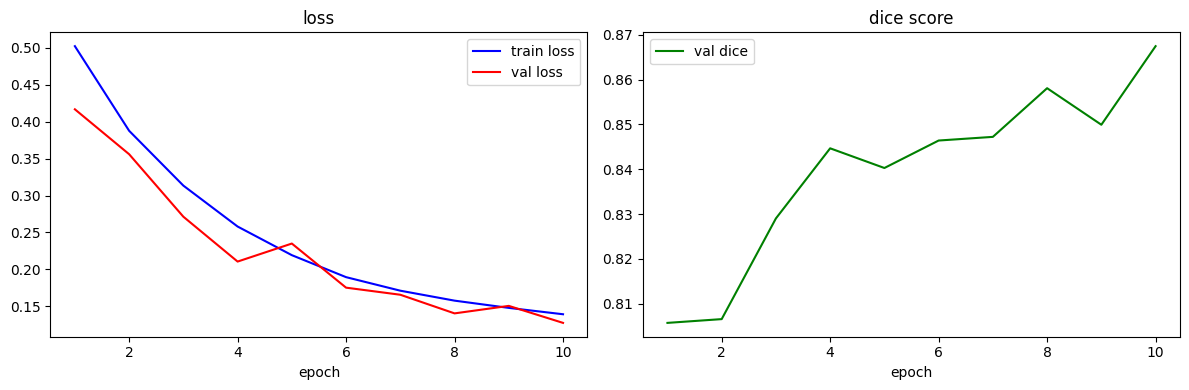

In [31]:
def plot_metrics(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], 'b', label='train loss')
    axes[0].plot(epochs, history["val_loss"],   'r', label='val loss')
    axes[0].set_title("loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(epochs, history["val_dice"], 'g', label='val dice')
    axes[1].set_title("dice score")
    axes[1].set_xlabel("epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=100)
    plt.show()

plot_metrics(history)


## testing

In [34]:
EPOCHS    = 10
LR        = 1e-4
BATCH     = 2
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using: {DEVICE}")
# ── model, optimizer, loss ──────────────────────
model     = ResNet34AttentionUNet().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
criterion = BCEDiceLoss()

using: cuda


In [36]:
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF

# ── 1. Configuration & Loading Weights ──────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the UNet model and load saved weights
model = ResNet34AttentionUNet().to(DEVICE)
weights_path = "/kaggle/working/best_attention_unet.pth"

try:
    model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    print(f"Successfully loaded best model weights from: {weights_path}")
except FileNotFoundError:
    print(f"Error: Could not find the weights file at {weights_path}")
    print("Please double check your Kaggle input path.")

model.eval()

# ── 2. Initialize Metrics ───────────────────────────────
test_loss = 0.0
test_dice = 0.0

# Counters for per-class pixel accuracy
correct_bg_pixels = 0
total_bg_pixels = 0

correct_nuclei_pixels = 0
total_nuclei_pixels = 0

# ── 3. Test Evaluation Loop ──────────────────────────────
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        
        # Forward pass
        preds = model(imgs)
        
        # Center crop masks to match model's output shape
        masks = TF.center_crop(masks, preds.shape[-2:])
        
        # Calculate loss & dice
        test_loss += criterion(preds, masks).item()
        test_dice += dice_score(preds, masks)
        
        # ── Per-Class Pixel Accuracy Calculations ──
        probs = torch.sigmoid(preds)
        binary_preds = (probs > 0.5).float()
        
        # FIX: Flatten tensors using .reshape(-1) to support non-contiguous memory layouts
        flat_preds = binary_preds.reshape(-1)
        flat_targets = masks.reshape(-1)
        
        # Background class (value = 0)
        bg_mask = (flat_targets == 0.0)
        total_bg_pixels += bg_mask.sum().item()
        correct_bg_pixels += ((flat_preds == 0.0) & bg_mask).sum().item()
        
        # Nuclei class (value = 1)
        nuclei_mask = (flat_targets == 1.0)
        total_nuclei_pixels += nuclei_mask.sum().item()
        correct_nuclei_pixels += ((flat_preds == 1.0) & nuclei_mask).sum().item()

# ── 4. Compute Averages ─────────────────────────────────
test_loss /= len(test_loader)
test_dice /= len(test_loader)

# Compute accuracies
bg_accuracy = (correct_bg_pixels / total_bg_pixels) * 100 if total_bg_pixels > 0 else 0.0
nuclei_accuracy = (correct_nuclei_pixels / total_nuclei_pixels) * 100 if total_nuclei_pixels > 0 else 0.0
overall_pixel_accuracy = ((correct_bg_pixels + correct_nuclei_pixels) / (total_bg_pixels + total_nuclei_pixels)) * 100

# ── 5. Print Results ────────────────────────────────────
print("\n" + "="*50)
print("             TEST SET EVALUATION RESULTS          ")
print("="*50)
print(f"Average Test Loss      : {test_loss:.4f}")
print(f"Average Test Dice Score: {test_dice:.4f}")
print("-"*50)
print(f"Background Accuracy (Class 0) : {bg_accuracy:.2f}%")
print(f"Nuclei Accuracy (Class 1)     : {nuclei_accuracy:.2f}%")
print(f"Overall Pixel Accuracy        : {overall_pixel_accuracy:.2f}%")
print("="*50)


Successfully loaded best model weights from: /kaggle/working/best_attention_unet.pth

             TEST SET EVALUATION RESULTS          
Average Test Loss      : 0.1356
Average Test Dice Score: 0.8559
--------------------------------------------------
Background Accuracy (Class 0) : 98.18%
Nuclei Accuracy (Class 1)     : 86.05%
Overall Pixel Accuracy        : 96.74%


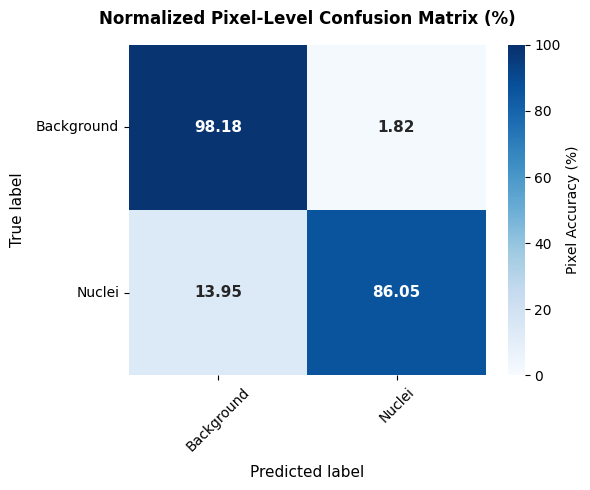

In [37]:
import numpy as np
import torch
import torchvision.transforms.functional as TF
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def generate_pixel_confusion_matrix(model, loader, device, num_classes=2, class_names=["Background", "Nuclei"]):
    """
    Computes a pixel-level confusion matrix incrementally over the loader 
    to avoid memory crashes, and plots a publication-quality normalized heatmap.
    """
    # 1. Initialize an empty confusion matrix
    total_cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    
    model.eval()
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            
            # Forward pass
            preds = model(imgs)
            
            # Align mask size to match prediction size (needed for crop-aligned U-Nets)
            if masks.shape[-2:] != preds.shape[-2:]:
                masks = TF.center_crop(masks, preds.shape[-2:])
            
            # 2. Get class predictions based on num_classes
            if num_classes == 2:
                # Binary segmentation (output has 1 channel, apply sigmoid)
                probs = torch.sigmoid(preds)
                pred_labels = (probs > 0.5).long().cpu().numpy().flatten()
                true_labels = masks.long().cpu().numpy().flatten()
            else:
                # Multi-class segmentation (output has C channels, apply argmax)
                pred_labels = torch.argmax(preds, dim=1).cpu().numpy().flatten()
                true_labels = masks.long().cpu().numpy().flatten()
            
            # 3. Filter out any invalid/ignored pixels (e.g., border ignore values like 255)
            valid_mask = (true_labels >= 0) & (true_labels < num_classes)
            true_labels = true_labels[valid_mask]
            pred_labels = pred_labels[valid_mask]
            
            # 4. Compute confusion matrix for current batch and accumulate
            batch_cm = confusion_matrix(true_labels, pred_labels, labels=list(range(num_classes)))
            total_cm += batch_cm

    # 5. Row-normalize to get percentage accuracy per class
    row_sums = total_cm.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1, row_sums)  # Prevent divide-by-zero
    cm_normalized = (total_cm.astype('float') / row_sums) * 100

    # 6. Plot the normalized heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2f",
        cmap="Blues",  # Matches the classic academic blue style
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True,
        cbar_kws={'label': 'Pixel Accuracy (%)'},
        vmin=0,
        vmax=100,
        annot_kws={"size": 11, "weight": "bold"}
    )
    
    plt.title("Normalized Pixel-Level Confusion Matrix (%)", fontsize=12, pad=15, weight='bold')
    plt.ylabel("True label", fontsize=11, labelpad=8)
    plt.xlabel("Predicted label", fontsize=11, labelpad=8)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.savefig("pixel_confusion_matrix.png", dpi=300, bbox_inches='tight')
    plt.show()

# --- Execution ---
# Run this by passing your model, test loader, and target device:
generate_pixel_confusion_matrix(
    model=model, 
    loader=test_loader, 
    device=DEVICE, 
    num_classes=2, 
    class_names=["Background", "Nuclei"]
)


Successfully loaded ResNet-34 Attention U-Net weights from: /kaggle/working/best_attention_unet.pth
Running test set evaluation...

       RESNET-34 ATTENTION U-NET TEST METRICS     
Dice Coefficient (F1)  : 0.8559
Mean IoU (Jaccard)     : 0.7574
Precision (PPV)        : 0.8581
Recall (Sensitivity)   : 0.8554
--------------------------------------------------
Hausdorff Distance 95  : 3.48 pixels



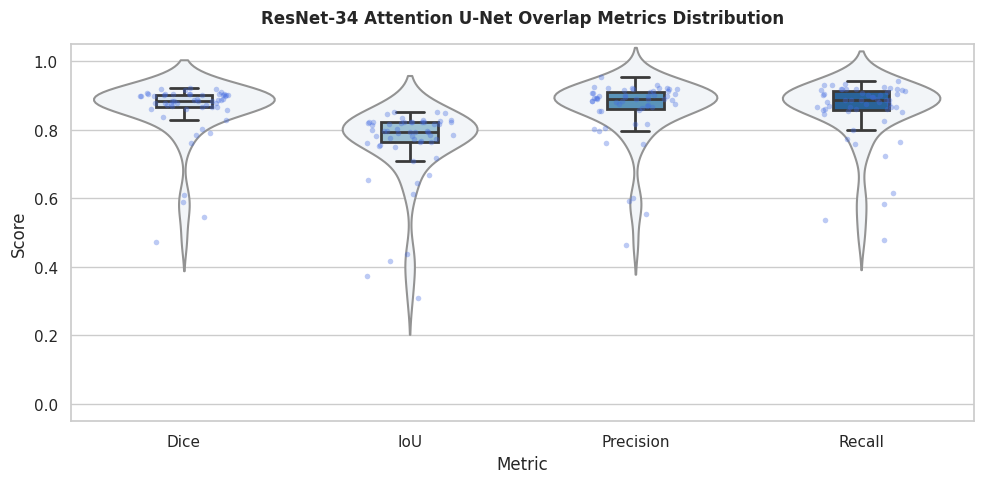

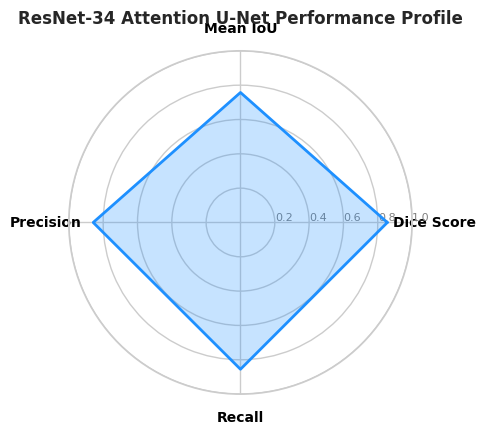

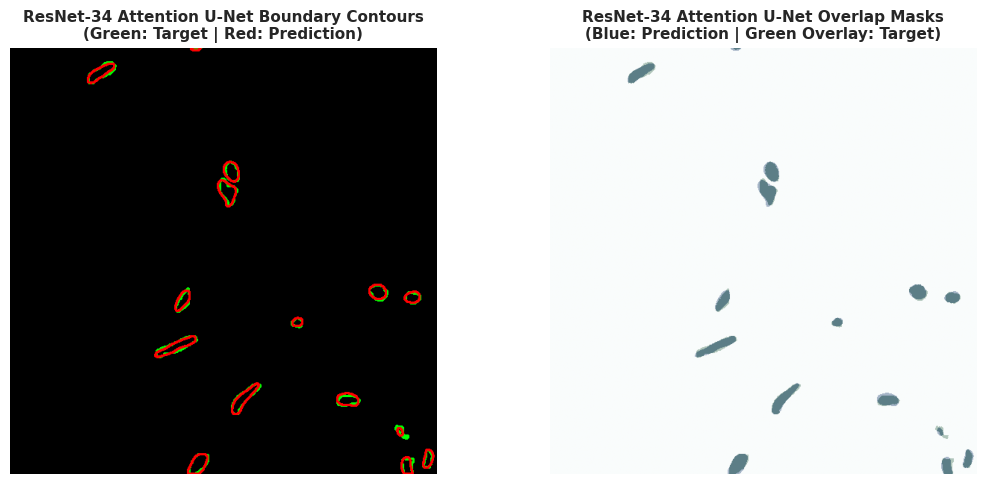

In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
from scipy.spatial import KDTree

# ── 1. Configuration & Loading Weights ──────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Update this path to where your ResNet-34 Attention U-Net weights are saved
weights_path = "/kaggle/working/best_attention_unet.pth"

# Instantiate the ResNet-34 Attention U-Net model
model = ResNet34AttentionUNet(num_classes=1, pretrained=False).to(DEVICE)

try:
    model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
    print(f"Successfully loaded ResNet-34 Attention U-Net weights from: {weights_path}")
except FileNotFoundError:
    print(f"Error: Could not find the weights file at {weights_path}")
    print("Please verify the filename where you saved the best model.")

model.eval()

# ── 2. Helper Functions for Metrics ──────────────────────
def compute_overlap_metrics(pred, target, threshold=0.5):
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    target_bin = (target > threshold).float()
    
    pred_flat = pred_bin.reshape(-1)
    target_flat = target_bin.reshape(-1)
    
    tp = torch.sum(pred_flat * target_flat).item()
    fp = torch.sum(pred_flat * (1.0 - target_flat)).item()
    fn = torch.sum((1.0 - pred_flat) * target_flat).item()
    
    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)
    iou = tp / (tp + fp + fn + 1e-7)
    dice = (2.0 * tp) / (2.0 * tp + fp + fn + 1e-7)
    
    return {"precision": precision, "recall": recall, "iou": iou, "dice": dice}

def compute_hd95(pred, target, threshold=0.5):
    pred_bin = (torch.sigmoid(pred) > threshold).cpu().numpy().astype(np.uint8).squeeze()
    target_bin = (target > threshold).cpu().numpy().astype(np.uint8).squeeze()
    
    pts_pred = np.argwhere(pred_bin > 0)
    pts_target = np.argwhere(target_bin > 0)
    
    if len(pts_pred) == 0 and len(pts_target) == 0:
        return 0.0
    if len(pts_pred) == 0 or len(pts_target) == 0:
        return 99.0
        
    tree_pred = KDTree(pts_pred)
    tree_target = KDTree(pts_target)
    
    d_target_to_pred, _ = tree_pred.query(pts_target)
    d_pred_to_target, _ = tree_target.query(pts_pred)
    
    hd95 = max(np.percentile(d_target_to_pred, 95), np.percentile(d_pred_to_target, 95))
    return hd95

# ── 3. Evaluation Loop ──────────────────────────────────
results = {"Dice": [], "IoU": [], "Precision": [], "Recall": [], "HD95": []}

print("Running test set evaluation...")
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds = model(imgs)
        
        # Align masks to prediction sizes
        if masks.shape[-2:] != preds.shape[-2:]:
            masks = TF.center_crop(masks, preds.shape[-2:])
        
        for i in range(imgs.size(0)):
            overlap = compute_overlap_metrics(preds[i:i+1], masks[i:i+1])
            hd = compute_hd95(preds[i], masks[i])
            
            results["Dice"].append(overlap["dice"])
            results["IoU"].append(overlap["iou"])
            results["Precision"].append(overlap["precision"])
            results["Recall"].append(overlap["recall"])
            results["HD95"].append(hd)

# Compute Averages
mean_dice = np.mean(results["Dice"])
mean_iou = np.mean(results["IoU"])
mean_precision = np.mean(results["Precision"])
mean_recall = np.mean(results["Recall"])
mean_hd95 = np.mean(results["HD95"])

# ── 4. Print Summary Report ─────────────────────────────
print("\n" + "="*50)
print("       RESNET-34 ATTENTION U-NET TEST METRICS     ")
print("="*50)
print(f"Dice Coefficient (F1)  : {mean_dice:.4f}")
print(f"Mean IoU (Jaccard)     : {mean_iou:.4f}")
print(f"Precision (PPV)        : {mean_precision:.4f}")
print(f"Recall (Sensitivity)   : {mean_recall:.4f}")
print("-"*50)
print(f"Hausdorff Distance 95  : {mean_hd95:.2f} pixels")
print("="*50 + "\n")

# ── 5. Plot 1: Violin & Box Plot (Distributions) ─────────
df_overlap = pd.DataFrame({
    "Dice": results["Dice"],
    "IoU": results["IoU"],
    "Precision": results["Precision"],
    "Recall": results["Recall"]
})
df_melted = df_overlap.melt(var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
sns.violinplot(x="Metric", y="Score", data=df_melted, inner=None, color="#f1f5f9", linewidth=1.5)
# Update this line in your plotting cell:
sns.boxplot(
    x="Metric", 
    y="Score", 
    data=df_melted, 
    width=0.25, 
    hue="Metric",       # Assign hue to avoid deprecation warning
    palette="Blues", 
    legend=False,       # Turn off the legend
    showfliers=False, 
    linewidth=2
)
sns.stripplot(x="Metric", y="Score", data=df_melted, color="royalblue", size=4, alpha=0.35, jitter=0.2)
plt.title("ResNet-34 Attention U-Net Overlap Metrics Distribution", fontsize=12, weight='bold', pad=15)
plt.ylim(-0.05, 1.05)
plt.ylabel("Score")
plt.tight_layout()
plt.show()

# ── 6. Plot 2: Radar Chart (Performance Profile) ──────────
categories = ['Dice Score', 'Mean IoU', 'Precision', 'Recall']
values = [mean_dice, mean_iou, mean_precision, mean_recall]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
values += values[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], categories, color='black', size=10, weight='bold')
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
plt.ylim(0, 1.0)
ax.plot(angles, values, linewidth=2, linestyle='solid', color='dodgerblue')
ax.fill(angles, values, color='dodgerblue', alpha=0.25)
plt.title("ResNet-34 Attention U-Net Performance Profile", fontsize=12, weight='bold', pad=20)
plt.tight_layout()
plt.show()

# ── 7. Plot 3: Boundary Contours (HD95 Visualisation) ─────
# Grab a single test sample to draw contours
for imgs, masks in test_loader:
    img_sample = imgs[0].to(DEVICE)
    mask_sample = masks[0].cpu().numpy().squeeze()
    
    pred_sample = model(img_sample.unsqueeze(0))
    pred_bin_sample = (torch.sigmoid(pred_sample) > 0.5).cpu().numpy().astype(np.uint8).squeeze()
    break

if mask_sample.shape != pred_bin_sample.shape:
    h_diff = mask_sample.shape[0] - pred_bin_sample.shape[0]
    w_diff = mask_sample.shape[1] - pred_bin_sample.shape[1]
    mask_sample = mask_sample[h_diff//2 : h_diff//2 + pred_bin_sample.shape[0], w_diff//2 : w_diff//2 + pred_bin_sample.shape[1]]

contours_true, _ = cv2.findContours((mask_sample > 0.5).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours_pred, _ = cv2.findContours((pred_bin_sample > 0.5).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contour_img = np.zeros((pred_bin_sample.shape[0], pred_bin_sample.shape[1], 3), dtype=np.uint8)
cv2.drawContours(contour_img, contours_true, -1, (0, 255, 0), 2)   # Green = Ground Truth
cv2.drawContours(contour_img, contours_pred, -1, (255, 0, 0), 2)   # Red = Prediction

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(contour_img)
axes[0].set_title("ResNet-34 Attention U-Net Boundary Contours\n(Green: Target | Red: Prediction)", fontsize=11, weight='bold')
axes[0].axis('off')

axes[1].imshow(pred_bin_sample, cmap='Blues', alpha=0.5)
axes[1].imshow(mask_sample, cmap='Greens', alpha=0.3)
axes[1].set_title("ResNet-34 Attention U-Net Overlap Masks\n(Blue: Prediction | Green Overlay: Target)", fontsize=11, weight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()
